# Эксперимент 2 - RoBERTa + Soft-Labels + BCEWithLogitsLoss

| | |
|---|---|
| **Модель** | `roberta-base` |
| **Разметка** | soft-labels (вещественные значения [0.0, 1.0]) |
| **Лосс** | BCEWithLogitsLoss |



## Импорты и версии библиотек

In [ ]:
import os
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import polars as pl
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import f1_score, hamming_loss, accuracy_score
from IPython.display import display

In [ ]:
packages = ['NumPy', 'Pandas', 'Polars', 'Matplotlib', 'Seaborn', 'Torch', 'Transformers']
package_objects = [np, pd, pl, mpl, sns, torch, __import__('transformers')]
versions = [obj.__version__ for obj in package_objects]

columns_order = ['№', 'Библиотека', 'Версия']
df_pkgs = (
    pl.DataFrame({columns_order[1]: packages, columns_order[2]: versions})
    .with_columns(pl.arange(1, pl.lit(len(packages)) + 1).alias(columns_order[0]))
    .select(columns_order)
)
display(df_pkgs)

№,Библиотека,Версия
i64,str,str
1,"""NumPy""","""2.0.2"""
2,"""Pandas""","""2.2.2"""
3,"""Polars""","""1.35.2"""
4,"""Matplotlib""","""3.10.0"""
5,"""Seaborn""","""0.13.2"""
6,"""Torch""","""2.10.0+cu128"""
7,"""Transformers""","""5.0.0"""


In [ ]:
CONFIG = {
    'model_name': 'roberta-base',
    'max_length': 64,
    'batch_size': 32,
    'num_epochs': 5,
    'learning_rate': 2e-5,
    'threshold': 0.5,
    'num_labels': 28,
    'data_dir': '.',
    'results_dir': 'results',
}

os.makedirs(CONFIG['results_dir'], exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [ ]:
EMOTIONS = [
    'admiration', 'amusement', 'approval', 'caring', 'desire',
    'excitement', 'gratitude', 'joy', 'love', 'optimism',
    'pride', 'relief', 'anger', 'annoyance', 'disappointment',
    'disapproval', 'disgust', 'embarrassment', 'fear', 'grief',
    'nervousness', 'remorse', 'sadness', 'confusion', 'curiosity',
    'realization', 'surprise', 'neutral',
]
NUM_EMOTIONS = len(EMOTIONS)
print(f'Эмоций: {NUM_EMOTIONS}')

Эмоций: 28


## Загрузка данных

soft-label уже есть из ноутбука Soft_Labels(raw_GoEmotions).  
Значения в столбцах эмоций - вещественные числа от 0.0 до 1.0.  
Для оценки метрик нужны и soft-labels (для лосса) и one-hot (для F1).  
Поэтому загрузила оба варианта.

In [ ]:
def load_data():
    soft_path = os.path.join(CONFIG['data_dir'], 'train_soft.csv')

    if not os.path.exists(soft_path):
        raise FileNotFoundError(
            'data/train_soft.csv не найден. '
        )

    # soft-labels для обучения
    train_soft = pd.read_csv(os.path.join(CONFIG['data_dir'], 'train_soft.csv'))
    val_soft = pd.read_csv(os.path.join(CONFIG['data_dir'], 'val_soft.csv'))
    test_soft = pd.read_csv(os.path.join(CONFIG['data_dir'], 'test_soft.csv'))

    # one-hot для подсчета F1
    train_oh = pd.read_csv(os.path.join(CONFIG['data_dir'], 'train.csv'))
    val_oh = pd.read_csv(os.path.join(CONFIG['data_dir'], 'val.csv'))
    test_oh = pd.read_csv(os.path.join(CONFIG['data_dir'], 'test.csv'))

    return train_soft, val_soft, test_soft, train_oh, val_oh, test_oh

train_soft, val_soft, test_soft, train_oh, val_oh, test_oh = load_data()

print(f'train_soft: {train_soft.shape}')
print(f'val_soft: {val_soft.shape}')
print(f'test_soft: {test_soft.shape}')

train_soft: (43410, 30)
val_soft: (5426, 30)
test_soft: (5427, 30)


In [ ]:
# Проверяем что soft-labels действительно вещественные
sample = train_soft[EMOTIONS].values
print(f'Тип значений: {sample.dtype}')
print(f'Мин / макс: {sample.min():.4f} / {sample.max():.4f}')
print(f'Доля дробных значений: {((sample > 0) & (sample < 1)).mean():.3f}')

# Пример soft-label вектора
print('\nПример soft-label:')
row = train_soft.iloc[0]
nonzero = {e: round(row[e], 3) for e in EMOTIONS if row[e] > 0}
print(f'текст: {row["text"]}')
print(f'soft: {nonzero}')

Тип значений: float64
Мин / макс: 0.0000 / 1.0000
Доля дробных значений: 0.088

Пример soft-label:
текст: Fast as [NAME] will carry me. Seriously uptown to downtown via Claiborne or broad isn’t that bad
soft: {'approval': np.float64(1.0)}


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])
print(f'Токенизатор: {CONFIG["model_name"]}')

max_len_path = os.path.join(CONFIG['data_dir'], 'max_length.txt')
if os.path.exists(max_len_path):
    with open(max_len_path) as f:
        CONFIG['max_length'] = int(f.read().strip())
    print(f'max_length: {CONFIG["max_length"]}')
else:
    print(f'max_length из конфига: {CONFIG["max_length"]}')

Токенизатор: roberta-base
max_length из конфига: 64


## Dataset и DataLoader


In [ ]:
class SoftEmotionDataset(Dataset):
    # Dataset с soft-labels для обучения
    # Возвращает soft_labels для лосса и onehot_labels для метрик
    def __init__(self, soft_df, onehot_df, tokenizer, max_length, emotions):
        self.texts = soft_df['text'].tolist()
        self.soft_labels = soft_df[emotions].values.astype(np.float32)
        self.onehot_labels = onehot_df[emotions].values.astype(np.float32)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'soft_labels': torch.tensor(self.soft_labels[idx], dtype=torch.float32),
            'onehot_labels': torch.tensor(self.onehot_labels[idx], dtype=torch.float32),
        }

In [ ]:
train_dataset = SoftEmotionDataset(train_soft, train_oh, tokenizer, CONFIG['max_length'], EMOTIONS)
val_dataset = SoftEmotionDataset(val_soft, val_oh, tokenizer, CONFIG['max_length'], EMOTIONS)
test_dataset = SoftEmotionDataset(test_soft, test_oh, tokenizer, CONFIG['max_length'], EMOTIONS)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False)

print(f'train batches: {len(train_loader)}')
print(f'val batches: {len(val_loader)}')
print(f'test batches: {len(test_loader)}')

batch = next(iter(train_loader))
print(f'soft_labels: {batch["soft_labels"].shape}')
print(f'onehot_labels: {batch["onehot_labels"].shape}')

train batches: 1357
val batches: 170
test batches: 170
soft_labels: torch.Size([32, 28])
onehot_labels: torch.Size([32, 28])


## Раздел 5 - Модель и лосс

Архитектура модели та же что в эксперименте 1 (c OneHot разметкой).  

In [ ]:
class RoBERTaForEmotions(nn.Module):
    def __init__(self, model_name, num_labels, dropout=0.1):
        super().__init__()
        self.roberta = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.roberta.config.hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]
        cls_output = self.dropout(cls_output)
        logits = self.classifier(cls_output)
        return logits

In [ ]:
model = RoBERTaForEmotions(CONFIG['model_name'], CONFIG['num_labels'])
model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Всего параметров: {total_params:,}')
print(f'Обучаемых: {trainable_params:,}')

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Всего параметров: 124,667,164
Обучаемых: 124,667,164


In [ ]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CONFIG['learning_rate'],
    weight_decay=0.01,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CONFIG['num_epochs'],
)

print('Лосс: BCEWithLogitsLoss')
print(f'Оптимизатор: AdamW, lr={CONFIG["learning_rate"]}')
print(f'Шедулер: CosineAnnealingLR, T_max={CONFIG["num_epochs"]}')

Лосс: BCEWithLogitsLoss
Оптимизатор: AdamW, lr=2e-05
Шедулер: CosineAnnealingLR, T_max=5


## Обучение

In [ ]:
def compute_metrics(labels, preds, threshold=0.5):
    binary_preds = (preds >= threshold).astype(int)
    return {
        'micro_f1': round(f1_score(labels, binary_preds, average='micro', zero_division=0), 4),
        'macro_f1': round(f1_score(labels, binary_preds, average='macro', zero_division=0), 4),
        'hamming': round(hamming_loss(labels, binary_preds), 4),
        'subset_acc': round(accuracy_score(labels, binary_preds), 4),
    }

In [ ]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    pbar = tqdm(loader, desc='train', leave=False)
    for batch in pbar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        soft_labels = batch['soft_labels'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss = criterion(logits, soft_labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    return total_loss / len(loader)


def eval_epoch(model, loader, criterion, device, threshold=0.5):
    model.eval()
    total_loss = 0
    all_onehot = []
    all_preds = []

    with torch.no_grad():
        pbar = tqdm(loader, desc='eval', leave=False)
        for batch in pbar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            soft_labels = batch['soft_labels'].to(device)
            onehot_labels = batch['onehot_labels']

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, soft_labels)
            total_loss += loss.item()

            probs = torch.sigmoid(logits).cpu().numpy()
            all_preds.append(probs)
            all_onehot.append(onehot_labels.numpy())

    all_preds = np.vstack(all_preds)
    all_onehot = np.vstack(all_onehot)
    metrics = compute_metrics(all_onehot, all_preds, threshold)
    metrics['loss'] = round(total_loss / len(loader), 4)
    return metrics, all_onehot, all_preds

In [ ]:
history = {
    'train_loss': [],
    'val_loss': [],
    'val_micro_f1': [],
    'val_macro_f1': [],
}

best_macro_f1 = 0
best_model_path = os.path.join(CONFIG['results_dir'], 'soft_bce_best.pt')

print('Начало обучения')
print(f'Эпох: {CONFIG["num_epochs"]}  |  Батч: {CONFIG["batch_size"]}  |  lr: {CONFIG["learning_rate"]}')
print('\n')

for epoch in range(1, CONFIG['num_epochs'] + 1):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_metrics, _, _ = eval_epoch(model, val_loader, criterion, DEVICE)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_metrics['loss'])
    history['val_micro_f1'].append(val_metrics['micro_f1'])
    history['val_macro_f1'].append(val_metrics['macro_f1'])

    if val_metrics['macro_f1'] > best_macro_f1:
        best_macro_f1 = val_metrics['macro_f1']
        torch.save(model.state_dict(), best_model_path)
        flag = ' <- best'
    else:
        flag = ''

    print(
        f'Epoch {epoch}/{CONFIG["num_epochs"]} | '
        f'train_loss: {train_loss:.4f} | '
        f'val_loss: {val_metrics["loss"]:.4f} | '
        f'micro_f1: {val_metrics["micro_f1"]:.4f} | '
        f'macro_f1: {val_metrics["macro_f1"]:.4f}'
        f'{flag}'
    )

print('\n')
print(f'Лучший Macro-F1 на val: {best_macro_f1:.4f}')

Начало обучения
Эпох: 5  |  Батч: 32  |  lr: 2e-05




train:   0%|          | 0/1357 [00:00<?, ?it/s]

eval:   0%|          | 0/170 [00:00<?, ?it/s]

Epoch 1/5 | train_loss: 0.1347 | val_loss: 0.1116 | micro_f1: 0.0515 | macro_f1: 0.0180 <- best


train:   0%|          | 0/1357 [00:00<?, ?it/s]

...

eval:   0%|          | 0/170 [00:00<?, ?it/s]

Epoch 4/5 | train_loss: 0.0998 | val_loss: 0.1071 | micro_f1: 0.0837 | macro_f1: 0.0247 <- best


train:   0%|          | 0/1357 [00:00<?, ?it/s]

eval:   0%|          | 0/170 [00:00<?, ?it/s]

Epoch 5/5 | train_loss: 0.0974 | val_loss: 0.1070 | micro_f1: 0.0858 | macro_f1: 0.0255 <- best


Лучший Macro-F1 на val: 0.0255


## Оценка на тесте

In [ ]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
print(f'Загружена лучшая модель: {best_model_path}')

test_metrics, test_labels, test_preds = eval_epoch(model, test_loader, criterion, DEVICE)

print()
print('РЕЗУЛЬТАТЫ НА TEST')
print(f'Micro-F1: {test_metrics["micro_f1"]}')
print(f'Macro-F1: {test_metrics["macro_f1"]}')
print(f'Hamming Loss: {test_metrics["hamming"]}')
print(f'Subset Acc: {test_metrics["subset_acc"]}')

Загружена лучшая модель: results/soft_bce_best.pt


eval:   0%|          | 0/170 [00:00<?, ?it/s]


РЕЗУЛЬТАТЫ НА TEST
Micro-F1: 0.0876
Macro-F1: 0.0283
Hamming Loss: 0.0603
Subset Acc: 0.0645


In [ ]:
binary_preds = (test_preds >= CONFIG['threshold']).astype(int)

per_class_f1 = f1_score(test_labels, binary_preds, average=None, zero_division=0)
df_per_class = pd.DataFrame({
    'emotion': EMOTIONS,
    'f1': per_class_f1.round(4),
    'support': test_labels.sum(axis=0).astype(int),
}).sort_values('f1', ascending=False).reset_index(drop=True)

print('Per-class F1 на test:')
display(df_per_class)

df_per_class.to_csv(
    os.path.join(CONFIG['results_dir'], 'soft_bce_per_class_f1.csv'),
    index=False
)
print('Сохранено: results/soft_bce_per_class_f1.csv')

Per-class F1 на test:


,emotion,f1,support
0,neutral,0.2337,1787
1,admiration,0.0835,504
2,disappointment,0.0748,78
3,amusement,0.0675,264
4,surprise,0.0478,141
5,love,0.0476,83
6,gratitude,0.0418,153
7,optimism,0.0372,151
8,approval,0.0312,198
9,joy,0.0249,284


Сохранено: results/soft_bce_per_class_f1.csv


## Визуализация

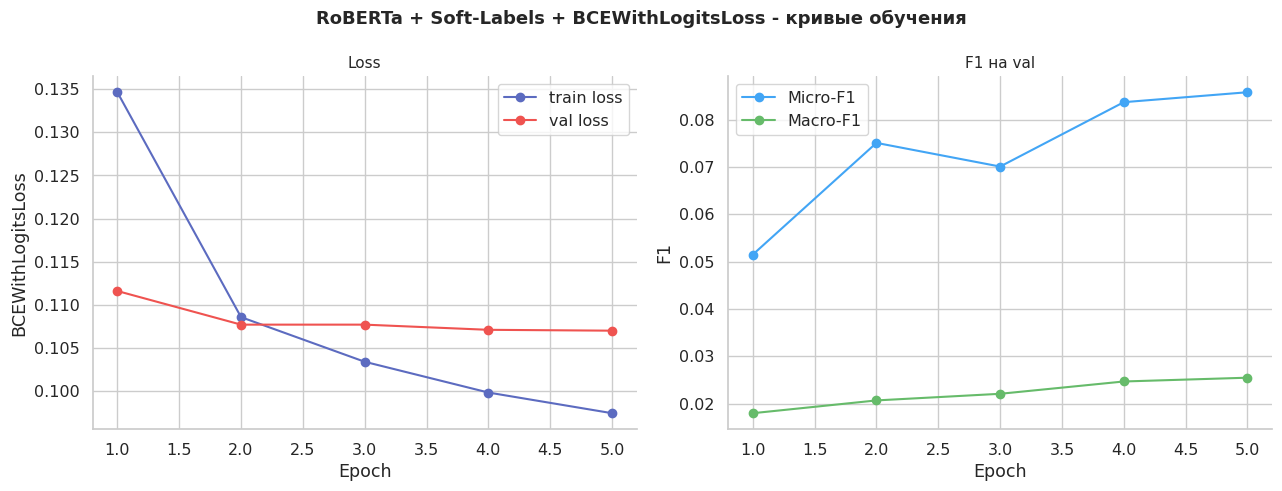

Сохранено: results/soft_bce_training_curves.png


In [ ]:
sns.set_theme(style='whitegrid', font_scale=1.05)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('RoBERTa + Soft-Labels + BCEWithLogitsLoss - кривые обучения', fontsize=13, fontweight='bold')

epochs_range = range(1, CONFIG['num_epochs'] + 1)

ax = axes[0]
ax.plot(epochs_range, history['train_loss'], 'o-', color='#5C6BC0', label='train loss')
ax.plot(epochs_range, history['val_loss'], 'o-', color='#EF5350', label='val loss')
ax.set_title('Loss', fontsize=11)
ax.set_xlabel('Epoch')
ax.set_ylabel('BCEWithLogitsLoss')
ax.legend()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax2 = axes[1]
ax2.plot(epochs_range, history['val_micro_f1'], 'o-', color='#42A5F5', label='Micro-F1')
ax2.plot(epochs_range, history['val_macro_f1'], 'o-', color='#66BB6A', label='Macro-F1')
ax2.set_title('F1 на val', fontsize=11)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('F1')
ax2.legend()
ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['results_dir'], 'soft_bce_training_curves.png'), dpi=150)
plt.show()
print('Сохранено: results/soft_bce_training_curves.png')

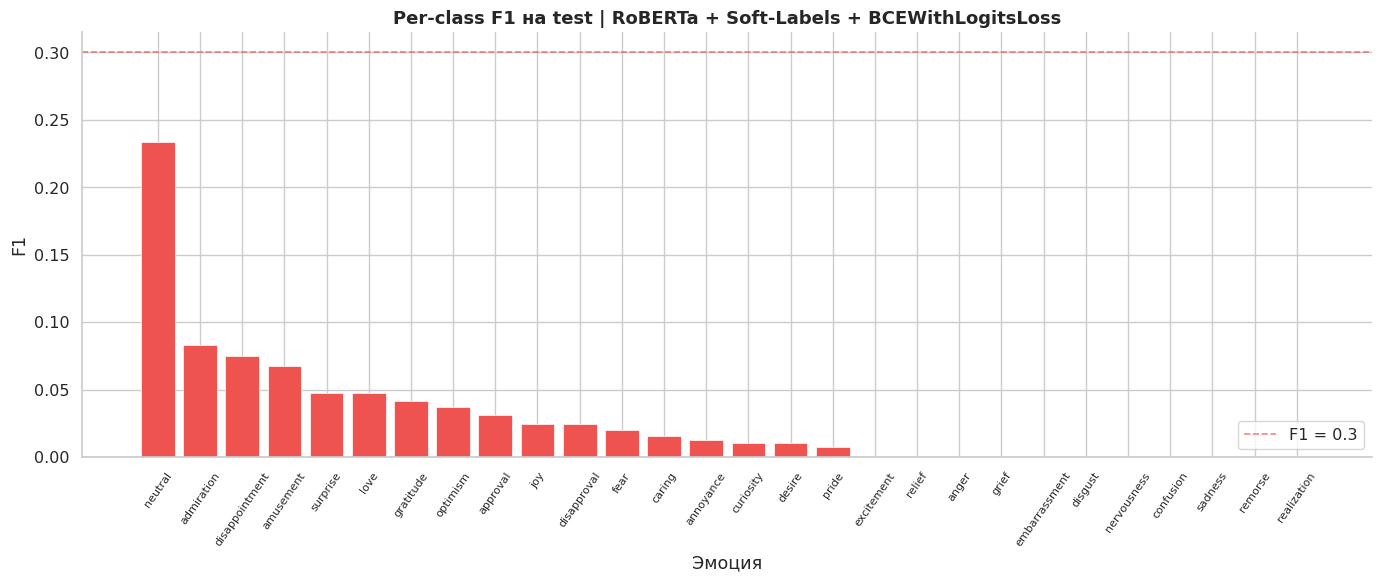

Сохранено: results/soft_bce_per_class_f1.png


In [ ]:
# Per-class F1 барплот
fig, ax = plt.subplots(figsize=(14, 6))

colors = ['#EF5350' if f < 0.3 else '#5C6BC0' for f in df_per_class['f1']]
ax.bar(
    df_per_class['emotion'],
    df_per_class['f1'],
    color=colors,
    edgecolor='white',
    linewidth=0.5,
)

ax.axhline(0.3, color='#EF5350', linestyle='--', linewidth=1.2, alpha=0.7, label='F1 = 0.3')
ax.set_title('Per-class F1 на test | RoBERTa + Soft-Labels + BCEWithLogitsLoss', fontsize=13, fontweight='bold')
ax.set_xlabel('Эмоция')
ax.set_ylabel('F1')
ax.tick_params(axis='x', rotation=55, labelsize=8)
ax.legend()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['results_dir'], 'soft_bce_per_class_f1.png'), dpi=150)
plt.show()
print('Сохранено: results/soft_bce_per_class_f1.png')

In [ ]:
# Сравнение per-class F1
exp1_class_path = os.path.join(CONFIG['results_dir'], 'onehot_bce_per_class_f1.csv')
if os.path.exists(exp1_class_path):
    df_exp1 = pd.read_csv(exp1_class_path)
    df_diff = df_per_class.merge(
        df_exp1[['emotion', 'f1']],
        on='emotion',
        suffixes=('_soft', '_onehot')
    )
    df_diff['delta'] = (df_diff['f1_soft'] - df_diff['f1_onehot']).round(4)
    df_diff = df_diff.sort_values('delta', ascending=False)

    fig, ax = plt.subplots(figsize=(14, 5))
    colors = ['#43A047' if d > 0 else '#EF5350' for d in df_diff['delta']]
    ax.bar(df_diff['emotion'], df_diff['delta'], color=colors, edgecolor='white', linewidth=0.5)
    ax.axhline(0, color='#333', linewidth=0.8)
    ax.set_title(
        'Изменение per-class F1: Exp2 (soft+BCE) - Exp1 (one-hot+BCE)\n'
        'Зеленый = soft-labels улучшили  |  Красный = ухудшили',
        fontsize=11, fontweight='bold'
    )
    ax.set_xlabel('Эмоция')
    ax.set_ylabel('delta F1')
    ax.tick_params(axis='x', rotation=55, labelsize=8)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['results_dir'], 'soft_vs_onehot_per_class_delta.png'), dpi=150)
    plt.show()
    print('Сохранено: results/soft_vs_onehot_per_class_delta.png')
else:
    print('onehot_bce_per_class_f1.csv не найден - сравнение недоступно')

onehot_bce_per_class_f1.csv не найден - сравнение недоступно


## Сохранение результатов

In [ ]:
results = {
    'experiment': 'soft_bce',
    'model': CONFIG['model_name'],
    'label_type': 'soft-labels',
    'loss': 'BCEWithLogitsLoss',
    'config': CONFIG,
    'val_best_macro_f1': best_macro_f1,
    'test_metrics': test_metrics,
    'history': history,
}

results_path = os.path.join(CONFIG['results_dir'], 'soft_bce_metrics.json')
with open(results_path, 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print(f'Сохранено: {results_path}')

Сохранено: results/soft_bce_metrics.json


### Подбор оптимального порога бинаризации

eval:   0%|          | 0/170 [00:00<?, ?it/s]

threshold=0.05  macro_f1=0.0554  micro_f1=0.1356
threshold=0.10  macro_f1=0.0464  micro_f1=0.1353
threshold=0.15  macro_f1=0.0432  micro_f1=0.1344
threshold=0.20  macro_f1=0.0421  micro_f1=0.1320
threshold=0.25  macro_f1=0.0396  micro_f1=0.1263
threshold=0.30  macro_f1=0.0373  micro_f1=0.1196
threshold=0.35  macro_f1=0.0320  micro_f1=0.1105
threshold=0.40  macro_f1=0.0312  micro_f1=0.1037
threshold=0.45  macro_f1=0.0284  micro_f1=0.0939
threshold=0.50  macro_f1=0.0255  micro_f1=0.0858

Лучший порог по Macro-F1: 0.05  (macro_f1=0.0554)

Результаты на test (threshold=0.05)
Micro-F1: 0.1394
Macro-F1: 0.0569
Hamming Loss: 0.1650
Subset Acc: 0.0090


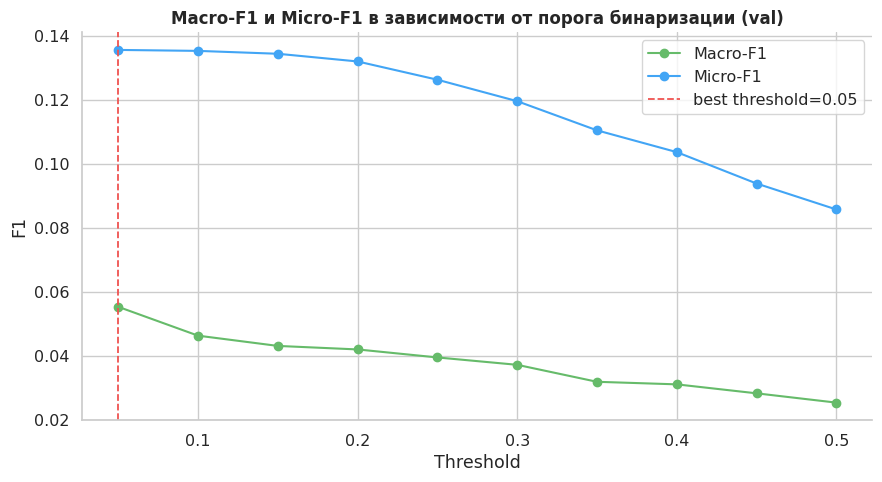

Сохранено: results/soft_bce_threshold_search.png


In [24]:
# предсказания на val с лучшей моделью
_, val_labels, val_preds = eval_epoch(model, val_loader, criterion, DEVICE)

# пороги
thresholds = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
results_thresh = []

for thresh in thresholds:
    binary = (val_preds >= thresh).astype(int)
    macro = f1_score(val_labels, binary, average='macro', zero_division=0)
    micro = f1_score(val_labels, binary, average='micro', zero_division=0)
    results_thresh.append({'threshold': thresh, 'macro_f1': round(macro, 4), 'micro_f1': round(micro, 4)})
    print(f'threshold={thresh:.2f}  macro_f1={macro:.4f}  micro_f1={micro:.4f}')

df_thresh = pd.DataFrame(results_thresh)
best_row = df_thresh.loc[df_thresh['macro_f1'].idxmax()]
best_threshold = best_row['threshold']
print(f'\nЛучший порог по Macro-F1: {best_threshold}  (macro_f1={best_row["macro_f1"]})')

# пересчет метрик на тесте с лучшим порогом
binary_test_best = (test_preds >= best_threshold).astype(int)
macro_test = f1_score(test_labels, binary_test_best, average='macro', zero_division=0)
micro_test = f1_score(test_labels, binary_test_best, average='micro', zero_division=0)
hamming_test = hamming_loss(test_labels, binary_test_best)
acc_test = accuracy_score(test_labels, binary_test_best)

print()
print(f'Результаты на test (threshold={best_threshold})')
print(f'Micro-F1: {micro_test:.4f}')
print(f'Macro-F1: {macro_test:.4f}')
print(f'Hamming Loss: {hamming_test:.4f}')
print(f'Subset Acc: {acc_test:.4f}')

# График: Macro-F1 и Micro-F1 в зависимости от порога
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df_thresh['threshold'], df_thresh['macro_f1'], 'o-', color='#66BB6A', label='Macro-F1')
ax.plot(df_thresh['threshold'], df_thresh['micro_f1'], 'o-', color='#42A5F5', label='Micro-F1')
ax.axvline(best_threshold, color='#EF5350', linestyle='--', linewidth=1.3, label=f'best threshold={best_threshold}')
ax.set_title('Macro-F1 и Micro-F1 в зависимости от порога бинаризации (val)', fontsize=12, fontweight='bold')
ax.set_xlabel('Threshold')
ax.set_ylabel('F1')
ax.legend()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['results_dir'], 'soft_bce_threshold_search.png'), dpi=150)
plt.show()
print('Сохранено: results/soft_bce_threshold_search.png')

### soft-labels с нормализацией по максимуму


In [25]:
# делим каждый soft-label вектор на его максимум
# чтобы самая сильная эмоция всегда была 1.0
# тогда BCEв том же диапазоне что и one-hot

class SoftEmotionDatasetNorm(Dataset):
    def __init__(self, soft_df, onehot_df, tokenizer, max_length, emotions):
        self.texts = soft_df['text'].tolist()
        self.soft_labels = soft_df[emotions].values.astype(np.float32)
        self.onehot_labels = onehot_df[emotions].values.astype(np.float32)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        soft = self.soft_labels[idx].copy()
        max_val = soft.max()
        if max_val > 0:
            soft = soft / max_val
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'soft_labels': torch.tensor(soft, dtype=torch.float32),
            'onehot_labels': torch.tensor(self.onehot_labels[idx], dtype=torch.float32),
        }

train_dataset_norm = SoftEmotionDatasetNorm(train_soft, train_oh, tokenizer, CONFIG['max_length'], EMOTIONS)
val_dataset_norm = SoftEmotionDatasetNorm(val_soft, val_oh, tokenizer, CONFIG['max_length'], EMOTIONS)
test_dataset_norm = SoftEmotionDatasetNorm(test_soft, test_oh, tokenizer, CONFIG['max_length'], EMOTIONS)

train_loader_norm = DataLoader(train_dataset_norm, batch_size=CONFIG['batch_size'], shuffle=True)
val_loader_norm = DataLoader(val_dataset_norm, batch_size=CONFIG['batch_size'], shuffle=False)
test_loader_norm = DataLoader(test_dataset_norm, batch_size=CONFIG['batch_size'], shuffle=False)

print('Датасеты с нормализацией созданы')

sample_norm = train_dataset_norm[0]['soft_labels'].numpy()
sample_orig = train_dataset[0]['soft_labels'].numpy()
nonzero_orig = {EMOTIONS[i]: round(float(sample_orig[i]), 3) for i in range(28) if sample_orig[i] > 0}
nonzero_norm = {EMOTIONS[i]: round(float(sample_norm[i]), 3) for i in range(28) if sample_norm[i] > 0}
print(f'Оригинал : {nonzero_orig}')
print(f'Норм. : {nonzero_norm}')

Датасеты с нормализацией созданы
Оригинал : {'approval': 1.0}
Норм. : {'approval': 1.0}


In [26]:
model_norm = RoBERTaForEmotions(CONFIG['model_name'], CONFIG['num_labels'])
model_norm = model_norm.to(DEVICE)

criterion_norm = nn.BCEWithLogitsLoss()
optimizer_norm = torch.optim.AdamW(model_norm.parameters(), lr=CONFIG['learning_rate'], weight_decay=0.01)
scheduler_norm = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_norm, T_max=CONFIG['num_epochs'])

history_norm = {'train_loss': [], 'val_loss': [], 'val_micro_f1': [], 'val_macro_f1': []}
best_macro_f1_norm = 0
best_model_path_norm = os.path.join(CONFIG['results_dir'], 'soft_bce_norm_best.pt')

print('Обучение с нормализованными soft-labels')
print()

for epoch in range(1, CONFIG['num_epochs'] + 1):
    train_loss = train_epoch(model_norm, train_loader_norm, optimizer_norm, criterion_norm, DEVICE)
    val_metrics, _, _ = eval_epoch(model_norm, val_loader_norm, criterion_norm, DEVICE)
    scheduler_norm.step()

    history_norm['train_loss'].append(train_loss)
    history_norm['val_loss'].append(val_metrics['loss'])
    history_norm['val_micro_f1'].append(val_metrics['micro_f1'])
    history_norm['val_macro_f1'].append(val_metrics['macro_f1'])

    if val_metrics['macro_f1'] > best_macro_f1_norm:
        best_macro_f1_norm = val_metrics['macro_f1']
        torch.save(model_norm.state_dict(), best_model_path_norm)
        flag = ' <- best'
    else:
        flag = ''

    print(
        f'Epoch {epoch}/{CONFIG["num_epochs"]} | '
        f'train_loss: {train_loss:.4f} | '
        f'val_loss: {val_metrics["loss"]:.4f} | '
        f'micro_f1: {val_metrics["micro_f1"]:.4f} | '
        f'macro_f1: {val_metrics["macro_f1"]:.4f}'
        f'{flag}'
    )

print()
print(f'Лучший Macro-F1 на val: {best_macro_f1_norm:.4f}')

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Обучение с нормализованными soft-labels



train:   0%|          | 0/1357 [00:00<?, ?it/s]

eval:   0%|          | 0/170 [00:00<?, ?it/s]

...

eval:   0%|          | 0/170 [00:00<?, ?it/s]

Epoch 4/5 | train_loss: 0.1230 | val_loss: 0.1395 | micro_f1: 0.1122 | macro_f1: 0.0360 <- best


train:   0%|          | 0/1357 [00:00<?, ?it/s]

eval:   0%|          | 0/170 [00:00<?, ?it/s]

Epoch 5/5 | train_loss: 0.1188 | val_loss: 0.1394 | micro_f1: 0.1158 | macro_f1: 0.0358

Лучший Macro-F1 на val: 0.0360


In [27]:
# оценка на тесте
model_norm.load_state_dict(torch.load(best_model_path_norm, map_location=DEVICE))
test_metrics_norm, test_labels_norm, test_preds_norm = eval_epoch(
    model_norm, test_loader_norm, criterion_norm, DEVICE
)

print('Результаты на test (soft + BCE + нормализация)')
print(f'Micro-F1: {test_metrics_norm["micro_f1"]}')
print(f'Macro-F1: {test_metrics_norm["macro_f1"]}')
print(f'Hamming Loss: {test_metrics_norm["hamming"]}')
print(f'Subset Acc: {test_metrics_norm["subset_acc"]}')
print()

print('Сравнение экспериментов:')
print(f'exp1 one-hot + BCE: Macro-F1 = 0.49  (baseline)')
print(f'exp2 soft + BCE: Macro-F1 = {test_metrics["macro_f1"]}')
print(f'exp2+ soft + BCE + норм.: Macro-F1 = {test_metrics_norm["macro_f1"]}')

eval:   0%|          | 0/170 [00:00<?, ?it/s]

Результаты на test (soft + BCE + нормализация)
Micro-F1: 0.1149
Macro-F1: 0.0391
Hamming Loss: 0.0761
Subset Acc: 0.0754

Сравнение экспериментов:
exp1 one-hot + BCE: Macro-F1 = 0.49  (baseline)
exp2 soft + BCE: Macro-F1 = 0.0283
exp2+ soft + BCE + норм.: Macro-F1 = 0.0391


**Выводы:** пока результат вышел хуже, чем с one-hot разметкой  (в этом эксперименте Macro-F1 = 0.028, при one-hot разметке вышло 0.49).

Проблема в том, что soft-labels содержат много маленьких дробных значений, а BCE Loss на таких таргетах дает другой масштаб лосса и модель учится предсказывать маленькие вероятности для всех классов. Попробовала добавить нормализацию, но все равно проблема остается. Нужно менять функцию лосса